In [1]:
from platform import python_version
print(python_version())

3.11.14


In [2]:
import os, sys, yaml
from pathlib import Path
from dotenv import load_dotenv

import numpy as npmtd
import pandas as pd
pd.set_option('display.width', 100)
pd.set_option('max_colwidth', 80)
pd.set_option("display.precision", 3)

import seaborn as sns
sns.set_context("notebook", font_scale=1.4)

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline

sys.path.insert(1, '../src/')

ROOT0 = Path("/home/flavio/uv/perturb_agent/")
ROOT_SRC = ROOT0 / "src"

if str(ROOT_SRC) not in sys.path:
    sys.path.append(str(ROOT_SRC))

print("ROOT0:", ROOT0)
print("ROOT_SRC added:", ROOT_SRC)

from libs.Basic import *
from libs.MTD_lib import MTD
from libs.GDC_lib import GDC
from libs.calc_degs_lib import CALC_DEGS
# from libs.dashcyto_lib import DASH_CYTO
from libs.config_lib import Config

from IPython.display import display, HTML
# display(HTML("<style>.container { width:100% !important; }</style>"))
display(HTML("<style>:root { --jp-notebook-max-width: 100% !important; }</style>"))

with open('../params.yml', 'r') as file:
    dic_yml = yaml.safe_load(file)

# print(dic_yml)

ROOT0: /home/flavio/uv/perturb_agent
ROOT_SRC added: /home/flavio/uv/perturb_agent/src


In [3]:
email = os.getenv('email')

i_project=0

project_list = dic_yml['project_list']
n = len(project_list)
project = project_list[i_project]

s_project_list = dic_yml['s_project_list']
s_project = s_project_list[i_project]
assert n==len(project_list), f"Error project_list: there are {n} projects"

PROG_ID = 'TCGA'
PSI_ID = 'TCGA-BRCA'
PSI_ID = 'TCGA-ACC'
PSI_ID = 'TCGA-CESC'
PSI_ID = 'TCGA-PAAD'

ROOT0_DATA = ROOT0 / "data"
root_colab = ROOT0_DATA / 'colab'
root_project = ROOT0_DATA / PROG_ID

disease = PSI_ID

root_project = create_dir(ROOT0_DATA, s_project)
root_disease = create_dir(root_project, PSI_ID)

CONTEXT_DISESE = 'xxxx'
context_disease = CONTEXT_DISESE

gene_protein = dic_yml['gene_protein']
s_omics = dic_yml['s_omics']

has_age = dic_yml['has_age']
has_gender = dic_yml['has_gender']

exp_normalization = dic_yml['exp_normalization']
normalization = 'quantile_norm' if exp_normalization == True else 'not_normalized'

LFC_cut_inf = dic_yml['LFC_cut_inf']
s_pathw_enrichm_method = dic_yml['s_pathw_enrichm_method']
ptw_min_num_of_degs_cut = dic_yml['ptw_min_num_of_degs_cut']

tolerance_pPMI = dic_yml['tolerance_pPMI']
type_sat_ptw_index = dic_yml['type_sat_ptw_index']
saturation_lfc_param = dic_yml['saturation_lfc_param']

pval_pathway_cutoff = dic_yml['pval_pathway_cutoff']
fdr_pathway_cutoff = dic_yml['fdr_pathway_cutoff']
num_of_genes_cutoff = dic_yml['num_of_genes_cutoff']
enr_db_list = dic_yml['enr_db_list']

case_list = dic_yml['case_list']
dic_case_list = dic_yml['dic_case_list']

std_filename      = dic_yml['std_filename']
std_filename_list = dic_yml['std_filename_list']

min_lfc_modulation = dic_yml['min_lfc_modulation']
num_of_genes_list  = dic_yml['num_of_genes_list']
pPMI_normalized  = dic_yml['pPMI_normalized']

#--- max len for formatting purposes
s_len_case  = dic_yml['s_len_case']

n_sentences = dic_yml['n_sentences']
run_list = dic_yml['run_list']
chosen_model_list = dic_yml['chosen_model_list']
i_dfp_list = dic_yml['i_dfp_list']
chosen_model_sampling = dic_yml['chosen_model_sampling']

fdr_ptw_cutoff_list = np.arange(0.05, 0.80, 0.05)
lfc_list = np.round(np.arange(1.0, -0.01, -.025), 3)
fdr_list = np.arange(0.05, 0.76, .01)

cfg = Config(root0=ROOT0, root_disease=root_disease, disease=disease, case_list=case_list)
case = case_list[0]

n_genes_annot_ptw, n_degs, n_degs_in_ptw, n_degs_not_in_ptw, degs_in_all_ratio = -1,-1,-1,-1,-1

LFC_cut, lfc_FDR_cut, n_degs, n_degs_up, n_degs_dw = cfg.get_best_lfc_cutoff(case, 'not_normalized')

print(f"project '{project}', s_project '{s_project}'")
print(f"G/P LFC cutoffs: lfc={LFC_cut:.3f}; fdr={lfc_FDR_cut:.3f} - LFC_cut_inf={LFC_cut_inf:.3f}")
print(f"Pathway cutoffs: pval={pval_pathway_cutoff:.3f}; fdr={fdr_pathway_cutoff:.3f}; num of genes={num_of_genes_cutoff}")

Best parameter file for LFC does not exist /home/flavio/uv/perturb_agent/data/TCGA/TCGA-PAAD/config/all_lfc_cutoffs_TCGA-PAAD.tsv
project 'TCGA', s_project 'TCGA'
G/P LFC cutoffs: lfc=1.000; fdr=0.050 - LFC_cut_inf=0.400
Pathway cutoffs: pval=0.050; fdr=0.050; num of genes=3


In [4]:
mtd = MTD(disease=disease, gene_protein=gene_protein, s_omics=s_omics, project=project, s_project=s_project, 
          root0=ROOT0, root0_data=ROOT0_DATA, prog_id=PROG_ID, psi_id=PSI_ID,
          case_list=case_list, dic_case_list=dic_case_list, has_age=has_age, has_gender=has_gender, exp_normalization=exp_normalization,
          std_filename=std_filename, std_filename_list=std_filename_list,
          geneset_num=0, ptw_min_num_of_degs_cut=ptw_min_num_of_degs_cut,
          tolerance_pPMI=tolerance_pPMI, s_pathw_enrichm_method=s_pathw_enrichm_method,
          LFC_cut_inf=LFC_cut_inf, fdr_ptw_cutoff_list=fdr_ptw_cutoff_list,
          num_of_genes_list=num_of_genes_list, lfc_list=lfc_list, fdr_list=fdr_list, 
          min_lfc_modulation=min_lfc_modulation, type_sat_ptw_index=type_sat_ptw_index,
          saturation_lfc_param=saturation_lfc_param, enr_db_list=enr_db_list, pPMI_normalized=pPMI_normalized)

print(">>> Roots", mtd.root0, mtd.root_disease)
case = case_list[0]
print(">>>", case)

mtd.cfg.set_default_best_lfc_cutoff(mtd.normalization, LFC_cut=1, lfc_FDR_cut=0.05)
ret, degs, degs_ensembl, dfdegs = mtd.open_case(case, prompt_verbose=False, verbose=False)
# print("\nEcho Parameters:")
# print(mtd.echo_parameters())

>>> Roots /home/flavio/uv/perturb_agent /home/flavio/uv/perturb_agent/data/TCGA/TCGA-PAAD
>>> Tumor


### Get all programs

In [5]:
gdc = GDC(root0=ROOT0, root0_data=ROOT0_DATA, memory_restriction=False)

#--------- chose a disease --------------------
DISEASE_ID = 'ACC'
DISEASE_ID = 'PAAD'

In [6]:
verbose=True
force=False

imax_tumor=250
imax_normal=50

gdc = GDC(root0=ROOT0, root0_data=ROOT0_DATA, memory_restriction=False)

exclude_prog_list=['CCLE']

dfn_tumor, dfn_normal, df_gtex, df_summ = gdc.get_all_data_from_disease(disease_id=DISEASE_ID, 
                                                           imax_tumor=imax_tumor, imax_normal=imax_normal,
                                                           exclude_prog_list=exclude_prog_list,
                                                           force=force, verbose=verbose)
print("\n")
print(">> dfn_tumor", dfn_tumor.shape)
print(">> dfn_normal", dfn_normal.shape)

df_summ

Table opened ((89, 12)) at '/home/flavio/uv/perturb_agent/data/gdc_to_cbioportal_study_mapping.tsv'
Table opened ((60616, 460)) at '/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/lfc/expression_tumor_counts_all_samples.tsv'
Table opened ((60616, 103)) at '/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/lfc/expression_normal_counts_all_samples.tsv'
Table opened ((74628, 17)) at '/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/lfc/expression_gtex_controls_counts.tsv'
Table opened ((3, 6)) at '/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/lfc/expression_summary.tsv'


>> dfn_tumor (60616, 460)
>> dfn_normal (60616, 103)


,prog_id,psi_id,disease_id,primary_site,n_tumors,n_normals
0,CPTAC,CPTAC-PAAD,PAAD,Pancreas,213,50
1,CPTAC,CPTAC-PAAD_GDC,PAAD,Pancreas,213,50
2,TCGA,TCGA-PAAD,PAAD,Pancreas,31,1


### Batch effect correction

In [7]:
force=False
verbose=True

perc_min_samples=0.25; top_n=10_000

df_combat = gdc.calc_cpm_merge_turmor_and_normal_batch_correction(dfn_tumor=dfn_tumor, dfn_normal=dfn_normal,
                                                                  perc_min_samples=perc_min_samples, top_n=top_n,
                                                                  force=force, verbose=verbose)
print(df_combat.shape)
df_combat.head(3)

Table opened ((10000, 458)) at '/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/lfc/Tumor_expression_sel_log_CPM_top_10000_genes_all_samples.tsv'
Table opened ((20024, 458)) at '/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/lfc/Tumor_expression_log_CPM_all_samples.tsv'
Table opened ((10000, 3)) at '/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/lfc/Tumor_expression_gene_annot_top_10000_genes_all_samples.tsv'
Table opened ((20024, 1463)) at '/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/lfc/cpm_log_all_genes_all_rows.tsv'
Table opened ((10000, 560)) at '/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/lfc/combat_log_exp_tumor_and_normal.tsv'
(10000, 560)


,geneid,symbol,biotype,1,2,3,4,5,6,7,...,548,549,550,551,552,553,554,555,556,557
0,ENSG00000270641,TSIX,lncRNA,13.955,13.211,13.898,13.478,13.710,11.679,13.350,...,2.868,3.028,5.113,2.322,3.620,4.659,13.198,4.548,3.652,14.046
1,ENSG00000262619,LINC00621,lncRNA,10.371,10.430,12.476,12.408,14.294,9.301,12.063,...,1.102,1.409,2.019,0.461,0.589,2.182,2.404,4.046,3.690,2.335
2,ENSG00000281383,FP671120.7,lncRNA,3.266,-0.078,10.497,-0.078,11.041,5.579,2.968,...,-0.146,-0.146,-0.146,-0.146,-0.146,-0.146,1.137,-0.146,0.574,-0.146


In [8]:
gdc.dfn.head(3)

,1,2,3,4,5,6,7,8,9,10,...,548,549,550,551,552,553,554,555,556,557
geneid,,,,,,,,,,,,,,,,,,,,,
ENSG00000270641,14.479,13.720,14.420,13.992,14.229,12.156,13.862,13.964,13.765,13.668,...,3.042,3.204,5.332,2.484,3.808,4.869,13.583,4.755,3.841,14.448
ENSG00000262619,10.816,10.877,12.968,12.899,14.828,9.721,12.547,10.455,9.238,13.277,...,1.383,1.696,2.320,0.728,0.859,2.488,2.714,4.393,4.029,2.643
ENSG00000281383,3.418,0.000,10.809,0.000,11.366,5.782,3.113,0.000,0.000,0.759,...,0.000,0.000,0.000,0.000,0.000,0.000,1.312,0.000,0.737,0.000


### Metadata

In [9]:
print(pd.crosstab(gdc.df_metadata["dataset"], gdc.df_metadata["condition"]))

condition       normal  tumor
dataset                      
CPTAC-PAAD          50    213
CPTAC-PAAD_GDC      50    213
TCGA-PAAD            0     31


In [ ]:
["BRD4", "ARID1A", "SMARCA4", "KMT2D"]

### Loop all clusters

In [10]:
disease_id=DISEASE_ID
imax_tumor=250
imax_normal=50
exclude_prog_list=['CCLE']
n_components = 10
n_umap_neighbors=5; min_umap_dist=0.2; umap_metric="euclidean"
method_hca="ward"; hca_criterion="maxclust"
LFC_cutoff=1; FDR_cutoff=0.05

force=False
verbose=False

group = 'Tumor'

n_clusters=5
print(f"Clusters: {n_clusters}")

# for silhouette
min_clusters = 3
max_clusters = n_clusters+2

df_cluster, df_pca, df_umap = gdc.cluster_PCA_HCA_UMAP(df_combat, group=group, n_clusters=n_clusters, 
                                                n_components=n_components, min_clusters=min_clusters, max_clusters=max_clusters,
                                                n_umap_neighbors=n_umap_neighbors, min_umap_dist=min_umap_dist, umap_metric=umap_metric,
                                                method_hca=method_hca, hca_criterion=hca_criterion,
                                                LFC_cutoff=LFC_cutoff, FDR_cutoff=FDR_cutoff,
                                                force=force, verbose=verbose)

df_hca = gdc.df_hca
df_metadata = gdc.df_metadata

lista = df_metadata[df_metadata.condition == 'normal'].index.to_list()
mini = np.min(lista)
maxi = np.max(lista)

normal_clusters = np.unique(df_hca[df_hca['sample'] >= mini].cluster)
normal_clusters


Clusters: 5


array([3, 4])

In [11]:
mini, maxi

(458, 557)

In [12]:
gdc.df_umap.tail(3)

,UMAP1,UMAP2,sample,cluster
554,5.194,2.388,555,1
555,-2.014,-4.761,556,1
556,-0.313,-8.137,557,1


In [13]:
dfall = gdc.dfall
dfall

,geneid,symbol,biotype,1,2,3,4,5,6,7,...,548,549,550,551,552,553,554,555,556,557
0,ENSG00000000005,TNMD,protein_coding,3.149,3.383,2.111,2.920,2.814,2.531,2.460,...,2.536,2.618,1.082,2.105,2.994,2.446,2.336,2.304,1.903,2.254
1,ENSG00000000419,DPM1,protein_coding,3.418,2.462,3.943,1.673,3.758,1.505,1.701,...,2.536,1.368,1.693,2.105,2.017,1.513,2.193,1.672,0.477,2.254
2,ENSG00000000457,SCYL3,protein_coding,6.607,6.504,7.211,7.223,7.385,7.459,6.810,...,5.976,6.528,6.244,6.075,6.088,6.188,6.431,5.866,5.803,6.529
3,ENSG00000000460,C1orf112,protein_coding,6.951,7.446,6.845,7.394,7.298,6.779,7.637,...,6.759,7.508,7.315,6.810,7.078,7.748,6.882,7.196,6.295,7.398
4,ENSG00000000971,CFH,protein_coding,2.212,0.496,2.708,2.171,4.541,0.452,0.536,...,2.423,0.481,2.451,1.977,0.000,1.988,0.778,2.304,2.408,1.813
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20019,ENSG00000288611,NPBWR1,protein_coding,3.938,0.496,3.836,0.524,5.004,1.680,2.460,...,0.905,0.481,1.693,0.000,1.455,1.079,0.562,1.672,0.000,0.505
20020,ENSG00000288612,AL133351.4,lncRNA,0.489,1.609,1.075,2.023,2.236,4.480,2.053,...,3.574,3.020,7.321,2.529,5.265,3.135,1.856,4.721,2.297,5.038
20021,ENSG00000288642,CDR1,protein_coding,6.854,2.566,9.519,3.949,8.535,5.713,4.761,...,7.463,7.407,6.449,6.805,6.270,7.023,4.828,8.240,7.913,6.957
20022,ENSG00000288663,AC073611.1,lncRNA,2.212,1.401,2.708,1.210,2.610,1.072,0.926,...,1.670,1.128,1.517,0.794,2.164,3.307,7.037,2.170,1.360,0.878


### Kennedy pathway

![Kennedy pathway](../figures/WP3933_kennety_pathway.png)

In [14]:
genesk_col = ['CHKA', 'CHKB', 'CHPT1', 'PCYT1A', 'PCYT1B', 'CEPT1']
genesk_eta = ['ETNK1', 'ETNK2', 'PCYT2', 'CEPT1', 'SELENOI']
# SGPL1 -  esfingolipídios / etanolamina
esfingo = ['SGPL1', 'SPHK1', 'SPHK2', 'SGPP1', 'SGPP2', 'SMPD1', 'SMPD2', 'SMPD3' ]
# 'PLA2G' expandir para remodelamento fosfolipídico
remodelamento =  ['LPCAT1', 'LPCAT2', 'LPCAT3', 'LPCAT4', 'PLA2G']

'''
KLF5 é um fator de transcrição que pode regular programas de proliferação, diferenciação epitelial, inflamação e metabolismo, 
incluindo síntese lipídica. 
Em câncer, especialmente em tumores epiteliais como pâncreas, cólon, mama e próstata, 
ele pode funcionar como um regulador de adaptação metabólica:

→ ativa genes metabólicos/lipogênicos
→ aumenta produção/remodelamento de fosfolipídios, ácidos graxos e membranas
→ sustenta proliferação, crescimento tumoral, adaptação ao estresse e invasão
'''
prolifera = ['KLF5']

genesk_all = list(np.unique(genesk_col + genesk_eta + esfingo + remodelamento + prolifera))
"; ".join(genesk_all)


'CEPT1; CHKA; CHKB; CHPT1; ETNK1; ETNK2; KLF5; LPCAT1; LPCAT2; LPCAT3; LPCAT4; PCYT1A; PCYT1B; PCYT2; PLA2G; SELENOI; SGPL1; SGPP1; SGPP2; SMPD1; SMPD2; SMPD3; SPHK1; SPHK2'

In [15]:
df2 = dfall[dfall.symbol.isin(genesk_all)]
print(df2.shape)
df2

(17, 1563)


,geneid,symbol,biotype,1,2,3,4,5,6,7,...,548,549,550,551,552,553,554,555,556,557
588,ENSG00000063176,SPHK2,protein_coding,5.222,4.831,4.387,5.289,4.324,4.836,4.582,...,5.576,5.327,4.961,3.937,5.390,5.879,5.180,5.776,5.823,5.144
1821,ENSG00000102554,KLF5,protein_coding,4.030,1.952,5.142,1.460,4.779,1.505,2.868,...,1.855,1.128,1.082,0.000,0.904,2.541,1.281,1.459,0.477,0.878
1869,ENSG00000103056,SMPD3,protein_coding,5.680,7.055,5.464,5.754,5.848,5.902,5.620,...,5.818,5.312,5.441,5.135,5.313,5.119,5.102,4.791,5.698,5.478
2552,ENSG00000110721,CHKA,protein_coding,5.628,6.256,5.976,6.115,5.609,4.249,5.328,...,5.057,4.919,5.312,5.009,4.851,4.315,4.988,4.721,4.961,5.259
2638,ENSG00000111666,CHPT1,protein_coding,5.159,4.558,3.454,3.286,2.372,2.107,2.573,...,4.717,5.223,4.347,4.218,3.900,3.685,3.551,2.833,2.937,4.400
2647,ENSG00000111684,LPCAT3,protein_coding,7.341,7.669,7.315,7.289,6.812,8.652,7.500,...,7.162,7.175,6.961,7.321,7.383,6.994,7.042,7.028,7.437,7.206
4494,ENSG00000134255,CEPT1,protein_coding,7.930,7.467,6.886,6.592,6.794,6.443,6.889,...,7.634,7.931,8.212,7.713,7.589,7.059,6.336,6.907,6.879,7.715
4655,ENSG00000135587,SMPD2,protein_coding,2.010,1.401,1.075,0.907,2.087,2.531,1.888,...,3.345,3.812,3.257,3.713,3.517,2.541,2.193,1.209,2.511,2.488
4944,ENSG00000138018,SELENOI,protein_coding,0.854,1.157,2.111,2.540,3.362,1.072,2.573,...,0.522,0.000,1.693,0.451,1.668,2.117,0.778,0.524,1.565,0.878
5064,ENSG00000139163,ETNK1,protein_coding,2.081,1.952,3.454,2.742,4.183,1.837,3.186,...,2.916,1.128,1.850,1.071,0.904,1.689,1.948,1.209,0.477,1.175


In [16]:
df_hca = gdc.df_hca
df_metadata = gdc.df_metadata

normal_clusters = np.unique(df_hca[df_hca['sample'] >= mini].cluster)
normal_clusters

array([3, 4])

In [17]:
df_hca.cluster.unique()

array([1, 5, 4, 2, 3])

In [18]:
nclu = 1

cols = gdc.df_hca[gdc.df_hca.cluster == nclu]['sample'].to_list()
cols = [str(x) for x in cols]

df2 = dfall[dfall.symbol.isin(genesk_all)]

df2 = df2[gdc.ANNOT_COLS + cols]
print(df2.shape)
df2


(17, 79)


,geneid,symbol,biotype,1,3,5,14,16,17,20,...,292,295,299,303,306,308,309,312,325,373
588,ENSG00000063176,SPHK2,protein_coding,5.222,4.387,4.324,3.048,3.474,3.035,3.328,...,5.046,4.548,4.788,4.917,5.207,3.834,3.468,3.772,3.674,3.897
1821,ENSG00000102554,KLF5,protein_coding,4.030,5.142,4.779,5.623,3.969,4.130,5.549,...,3.840,5.692,5.426,4.201,4.275,4.783,4.141,3.772,4.779,4.701
1869,ENSG00000103056,SMPD3,protein_coding,5.680,5.464,5.848,5.529,4.743,5.208,5.512,...,4.810,5.910,5.344,5.216,5.941,5.041,4.347,5.249,4.900,5.415
2552,ENSG00000110721,CHKA,protein_coding,5.628,5.976,5.609,4.576,4.600,4.675,5.263,...,5.635,5.503,5.282,4.356,5.376,6.332,5.580,5.725,5.883,5.758
2638,ENSG00000111666,CHPT1,protein_coding,5.159,3.454,2.372,5.119,4.185,3.944,3.639,...,2.857,3.422,3.090,3.829,4.093,3.916,4.043,3.900,3.215,4.066
2647,ENSG00000111684,LPCAT3,protein_coding,7.341,7.315,6.812,6.585,6.292,6.956,6.173,...,6.571,6.787,7.273,6.237,7.377,7.140,7.277,7.217,8.183,7.539
4494,ENSG00000134255,CEPT1,protein_coding,7.930,6.886,6.794,7.871,8.035,7.715,7.222,...,8.236,7.503,6.876,6.756,6.845,7.810,7.453,7.628,7.050,8.130
4655,ENSG00000135587,SMPD2,protein_coding,2.010,1.075,2.087,1.847,1.819,2.133,1.141,...,0.273,1.984,2.026,1.919,3.549,1.964,1.732,0.397,2.245,1.160
4944,ENSG00000138018,SELENOI,protein_coding,0.854,2.111,3.362,2.504,2.821,1.824,3.042,...,2.857,2.601,2.767,3.328,2.832,2.851,3.468,2.355,3.871,3.223
5064,ENSG00000139163,ETNK1,protein_coding,2.081,3.454,4.183,3.297,3.922,3.243,4.814,...,4.224,1.638,4.229,2.163,3.452,4.169,3.863,2.441,3.790,3.359


In [19]:
df3 = df2.set_index('symbol')[cols]
df3.mean(axis=1)

symbol
SPHK2      4.011
KLF5       4.525
SMPD3      5.283
CHKA       5.400
CHPT1      3.652
LPCAT3     7.148
CEPT1      7.508
SMPD2      1.625
SELENOI    2.478
ETNK1      3.227
ETNK2      2.841
LPCAT1     2.898
PCYT1A     4.778
SGPP2      4.936
SGPL1      4.101
SPHK1      3.012
PCYT2      2.326
dtype: float64

In [20]:
dic = {'nclu': nclu, 'symbol': df3.index, 'mu': np.array(df3.mean(axis=1)), 'std': np.array(df3.std(axis=1)), 'n': len(cols)}
df = pd.DataFrame(dic)
df

,nclu,symbol,mu,std,n
0,1,SPHK2,4.011,0.831,76
1,1,KLF5,4.525,0.793,76
2,1,SMPD3,5.283,0.698,76
3,1,CHKA,5.400,0.531,76
4,1,CHPT1,3.652,0.765,76
5,1,LPCAT3,7.148,0.474,76
6,1,CEPT1,7.508,0.583,76
7,1,SMPD2,1.625,0.806,76
8,1,SELENOI,2.478,0.855,76
9,1,ETNK1,3.227,0.781,76


In [21]:
df_list = []

for nclu, group, order in [(1,'SEV1', 4), (2,'SEV2', 3), (3,'CTRL', 0), (5,'MILD', 2)]:

    if nclu == 3:
        cols = gdc.df_hca[gdc.df_hca.cluster == 3]['sample'].to_list() + gdc.df_hca[gdc.df_hca.cluster == 4]['sample'].to_list()

        cols = set(cols)
        cols_ctrl = set(np.arange(mini, maxi+1))
        cols_other = list(cols-cols_ctrl)
        print(f"Cluster 3-4: CTRL: {len(cols_ctrl)} - Others:{len(cols_other)}")

        for case in ['ctrl', 'other']:
            if case == 'ctrl':
                cols = cols_ctrl
                nclu2 = 0
                group = 'CTRL'
                order = 0
            else:
                cols = cols_other
                nclu2 = 3
                group = 'BEGIN'
                order = 1

            cols = [str(x) for x in cols]
            print(f"Cluster {nclu2} ({group}): {len(cols)} - {';'.join(cols)}")

            df2 = dfall[dfall.symbol.isin(genesk_all)]
            df2 = df2[gdc.ANNOT_COLS + cols]

            df3 = df2.set_index('symbol')[cols]

            dic = {'nclu': nclu2, 'group': group, 'order': order, 'symbol': df3.index, 'mu': np.array(df3.mean(axis=1)), 'std': np.array(df3.std(axis=1)), 'n': len(cols)}
            dfa = pd.DataFrame(dic)

            df_list.append(dfa)
    else:
        cols = gdc.df_hca[gdc.df_hca.cluster == nclu]['sample'].to_list()

        cols = [str(x) for x in cols]
        print(f"Cluster {nclu} ({group}): {len(cols)} - {';'.join(cols)}")

        df2 = dfall[dfall.symbol.isin(genesk_all)]
        df2 = df2[gdc.ANNOT_COLS + cols]

        df3 = df2.set_index('symbol')[cols]

        dic = {'nclu': nclu, 'group': group, 'order': order, 'symbol': df3.index, 'mu': np.array(df3.mean(axis=1)), 'std': np.array(df3.std(axis=1)), 'n': len(cols)}
        dfa = pd.DataFrame(dic)

        df_list.append(dfa)

df = pd.concat(df_list, ignore_index=True)
df = df.sort_values(['symbol', 'order'])

df

Cluster 1 (SEV1): 76 - 1;3;5;14;16;17;20;22;23;25;28;30;32;33;38;39;42;43;45;52;55;56;63;65;70;73;75;77;79;82;86;90;93;95;96;99;112;160;214;216;218;219;228;230;231;234;236;237;239;242;244;246;247;252;253;256;257;259;266;269;276;278;283;286;288;290;292;295;299;303;306;308;309;312;325;373
Cluster 2 (SEV2): 44 - 11;36;48;51;59;61;67;85;89;101;102;104;111;120;127;131;142;144;146;151;155;163;225;250;262;265;272;274;280;298;302;314;315;317;324;333;340;344;355;357;359;364;368;376
Cluster 3-4: CTRL: 100 - Others:188
Cluster 0 (CTRL): 100 - 512;513;514;515;516;517;518;519;520;521;522;523;524;525;526;527;528;529;530;531;532;533;534;535;536;537;538;539;540;541;542;543;544;545;546;547;548;549;550;551;552;553;554;555;556;557;458;459;460;461;462;463;464;465;466;467;468;469;470;471;472;473;474;475;476;477;478;479;480;481;482;483;484;485;486;487;488;489;490;491;492;493;494;495;496;497;498;499;500;501;502;503;504;505;506;507;508;509;510;511
Cluster 3 (BEGIN): 188 - 10;103;105;106;107;108;109;110;113;11

,nclu,group,order,symbol,mu,std,n
40,0,CTRL,0,CEPT1,7.394,0.563,100
57,3,BEGIN,1,CEPT1,7.260,0.567,188
74,5,MILD,2,CEPT1,6.779,0.892,149
23,2,SEV2,3,CEPT1,6.334,1.201,44
6,1,SEV1,4,CEPT1,7.508,0.583,76
...,...,...,...,...,...,...,...
34,0,CTRL,0,SPHK2,4.815,0.790,100
51,3,BEGIN,1,SPHK2,4.707,0.681,188
68,5,MILD,2,SPHK2,4.779,0.627,149
17,2,SEV2,3,SPHK2,4.905,1.258,44


In [22]:
df.group.unique()

array(['CTRL', 'BEGIN', 'MILD', 'SEV2', 'SEV1'], dtype=object)

In [23]:
symbols = df.symbol.unique()

ctrl_mu = (
    df[df["group"] == "CTRL"]
    .set_index("symbol")["mu"]
    .to_dict()
)

ctrl_std = (
    df[df["group"] == "CTRL"]
    .set_index("symbol")["std"]
    .to_dict()
)

ctrl_mu, ctrl_std

({'CEPT1': 7.393812103367452,
  'CHKA': 5.011660616157314,
  'CHPT1': 3.6310203816609605,
  'ETNK1': 1.373434779207341,
  'ETNK2': 3.4907965617555794,
  'KLF5': 0.9329409209102792,
  'LPCAT1': 2.3924928047398843,
  'LPCAT3': 7.234758645000498,
  'PCYT1A': 2.184449421851825,
  'PCYT2': 2.6088212351613085,
  'SELENOI': 1.1572393377109107,
  'SGPL1': 2.524988929638296,
  'SGPP2': 4.928484215595105,
  'SMPD2': 2.90472191192183,
  'SMPD3': 5.533053963701891,
  'SPHK1': 4.341070862796743,
  'SPHK2': 4.814877197792303},
 {'CEPT1': 0.5634901695015806,
  'CHKA': 0.484309710798406,
  'CHPT1': 0.7388152424133368,
  'ETNK1': 0.6631198105961457,
  'ETNK2': 0.9470037248647784,
  'KLF5': 0.7178065678803897,
  'LPCAT1': 1.0557110867772892,
  'LPCAT3': 0.26827871031107425,
  'PCYT1A': 0.8376702519342848,
  'PCYT2': 0.6600417456466429,
  'SELENOI': 0.5578589031020389,
  'SGPL1': 0.7149615698925289,
  'SGPP2': 0.9769329026138955,
  'SMPD2': 0.7191884784548759,
  'SMPD3': 0.46334824082157094,
  'SPHK1': 0

In [24]:
df["std"] = df.apply(
    lambda r:  ctrl_std[r["symbol"]],
    axis=1
)

df["mu_ref"] = df.apply(
    lambda r: r["mu"] - ctrl_mu[r["symbol"]],
    axis=1
)

df["std_ref"] = df.apply(
    lambda r: np.sqrt(r["std"]**2 + ctrl_std[r["symbol"]]**2),
    axis=1
)

df['sem_ref'] = df['std_ref'] / np.sqrt(df['n'])
df['ci_inf_ref'] = df['mu_ref'] - 1.96 * df['sem_ref']
df['ci_sup_ref'] = df['mu_ref'] + 1.96 * df['sem_ref']


cols = ['nclu', 'group', 'order', 'symbol',  'mu_ref', 'ci_inf_ref', 'ci_sup_ref', 'sem_ref', 'mu', 'std', 'n']
df = df[cols]
df.reset_index(drop=True, inplace=True)
df.head(5)

,nclu,group,order,symbol,mu_ref,ci_inf_ref,ci_sup_ref,sem_ref,mu,std,n
0,0,CTRL,0,CEPT1,0.000,-0.156,0.156,0.080,7.394,0.563,100
1,3,BEGIN,1,CEPT1,-0.134,-0.248,-0.020,0.058,7.260,0.563,188
2,5,MILD,2,CEPT1,-0.615,-0.743,-0.487,0.065,6.779,0.563,149
3,2,SEV2,3,CEPT1,-1.060,-1.295,-0.824,0.120,6.334,0.563,44
4,1,SEV1,4,CEPT1,0.114,-0.065,0.293,0.091,7.508,0.563,76


In [ ]:
fname = 'kennedy_and_other_gene_per_subtypes.tsv'
pdwritecsv(df, fname, gdc.root_mprog_lfc)

True

In [26]:
gene = 'CHKA'

df[df.symbol == gene]

,nclu,group,order,symbol,mu_ref,ci_inf_ref,ci_sup_ref,sem_ref,mu,std,n
5,0,CTRL,0,CHKA,0.000,-0.134,0.134,0.068,5.012,0.484,100
6,3,BEGIN,1,CHKA,0.154,0.056,0.252,0.050,5.166,0.484,188
7,5,MILD,2,CHKA,0.359,0.249,0.469,0.056,5.371,0.484,149
8,2,SEV2,3,CHKA,-0.790,-0.993,-0.588,0.103,4.221,0.484,44
9,1,SEV1,4,CHKA,0.388,0.234,0.542,0.079,5.400,0.484,76


### Gene evolution - Kennedy pathway

Genes present: ['CEPT1', 'CHKA', 'CHPT1', 'ETNK1', 'ETNK2', 'KLF5', 'LPCAT1', 'LPCAT3', 'PCYT1A', 'PCYT2', 'SELENOI', 'SGPL1', 'SGPP2', 'SMPD2', 'SMPD3', 'SPHK1', 'SPHK2']
Genes missing: ['CHKB', 'LPCAT2', 'LPCAT4', 'PCYT1B', 'PLA2G', 'SGPP1', 'SMPD1']


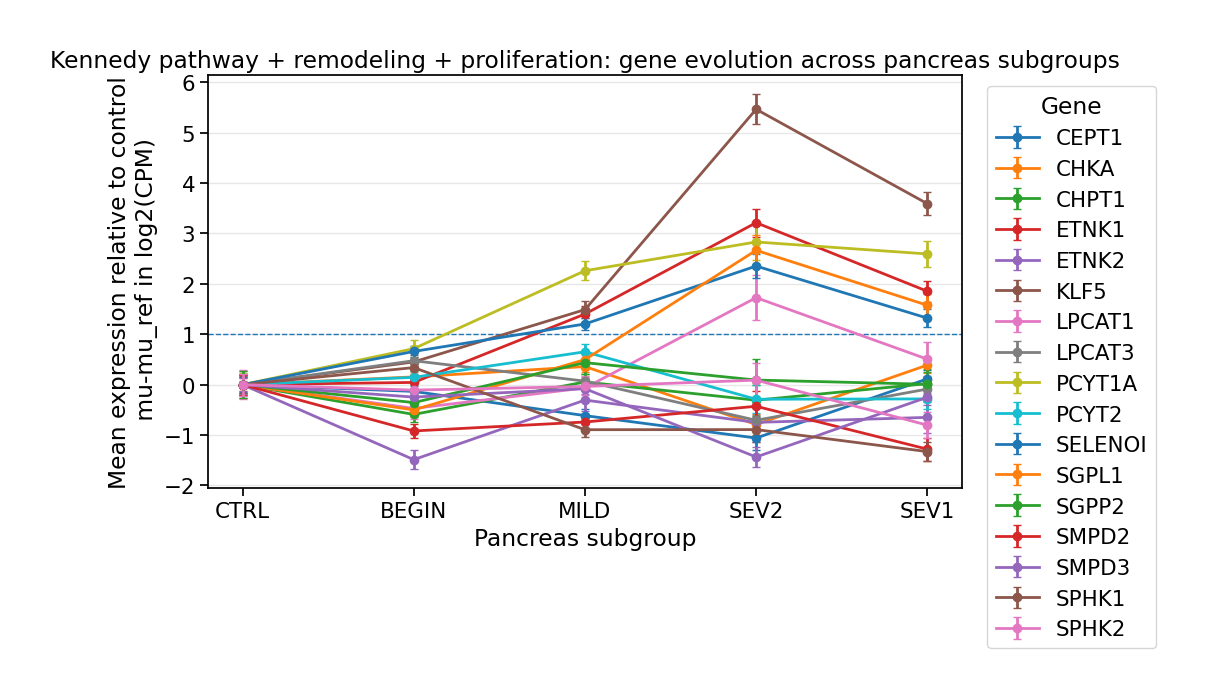

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Kennedy pathway genes
# ============================================================

genesk_col = ["CHKA", "CHKB", "CHPT1", "PCYT1A", "PCYT1B"]
genesk_eta = ["SGPL1", "ETNK1", "ETNK2", "PCYT2", "CEPT1"]
others =  ['LPCAT1']

genesk_col = ['CHKA', 'CHKB', 'CHPT1', 'PCYT1A', 'PCYT1B', 'CEPT1']
genesk_eta = ['ETNK1', 'ETNK2', 'PCYT2', 'CEPT1', 'SELENOI']
# SGPL1 -  esfingolipídios / etanolamina
esfingo = ['SGPL1', 'SPHK1', 'SPHK2', 'SGPP1', 'SGPP2', 'SMPD1', 'SMPD2', 'SMPD3' ]
# 'PLA2G' expandir para remodelamento fosfolipídico
remodelamento =  ['LPCAT1', 'LPCAT2', 'LPCAT3', 'LPCAT4', 'PLA2G']
proliferacao = ['KLF5']

# Kennedy and others
kennedy_genes = ['LPCAT1', 'ETNK1', 'PCYT2', 'KLF5']
kennedy_genes = ['LPCAT1', 'ETNK1','ETNK2', 'PCYT2', 'KLF5', 'SPHK1', 'PCYT1A', 'SGPL1', 'CEPT1', 'SMPD2']
kennedy_genes = list(np.unique(genesk_col + genesk_eta + esfingo + remodelamento + proliferacao))

# ============================================================
# Keep only genes present in the uploaded table
# ============================================================

genes_present = [g for g in kennedy_genes if g in df["symbol"].unique()]
genes_missing = [g for g in kennedy_genes if g not in df["symbol"].unique()]

print("Genes present:", genes_present)
print("Genes missing:", genes_missing)


# ============================================================
# Define biological group order
# ============================================================

group_order = ["CTRL", "BEGIN", "MILD", "SEV2", "SEV1"]

dff = df[df["symbol"].isin(genes_present)].copy()
dff["group"] = pd.Categorical(
    dff["group"],
    categories=group_order,
    ordered=True
)

dff = dff.sort_values(["symbol", "group"])


# ============================================================
# Plot 1:
# each gene evolution across groups
# ============================================================

fig, ax = plt.subplots(figsize=(11, 6))

x_positions = np.arange(len(group_order))

for gene in genes_present:
    dfa = dff[dff["symbol"] == gene].sort_values("group")

    y = dfa["mu_ref"].to_numpy()

    yerr_lower = y - dfa["ci_inf_ref"].to_numpy()
    yerr_upper = dfa["ci_sup_ref"].to_numpy() - y
    yerr = np.vstack([yerr_lower, yerr_upper])

    ax.errorbar(
        x_positions,
        y,
        yerr=yerr,
        marker="o",
        linewidth=2,
        capsize=3,
        label=gene,
    )

ax.axhline(1.0, linestyle="--", linewidth=1)

ax.set_xticks(x_positions)
ax.set_xticklabels(group_order)

ax.set_xlabel("Pancreas subgroup")
ax.set_ylabel("Mean expression relative to control\n mu-mu_ref in log2(CPM)")
ax.set_title("Kennedy pathway + remodeling + proliferation: gene evolution across pancreas subgroups")

ax.legend(
    title="Gene",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.grid(True, axis="y", alpha=0.3)

fig.tight_layout()
fig.savefig("kennedy_gene_evolution_mu_ref.png", dpi=300, bbox_inches="tight")
plt.show()




### 2 genes difference

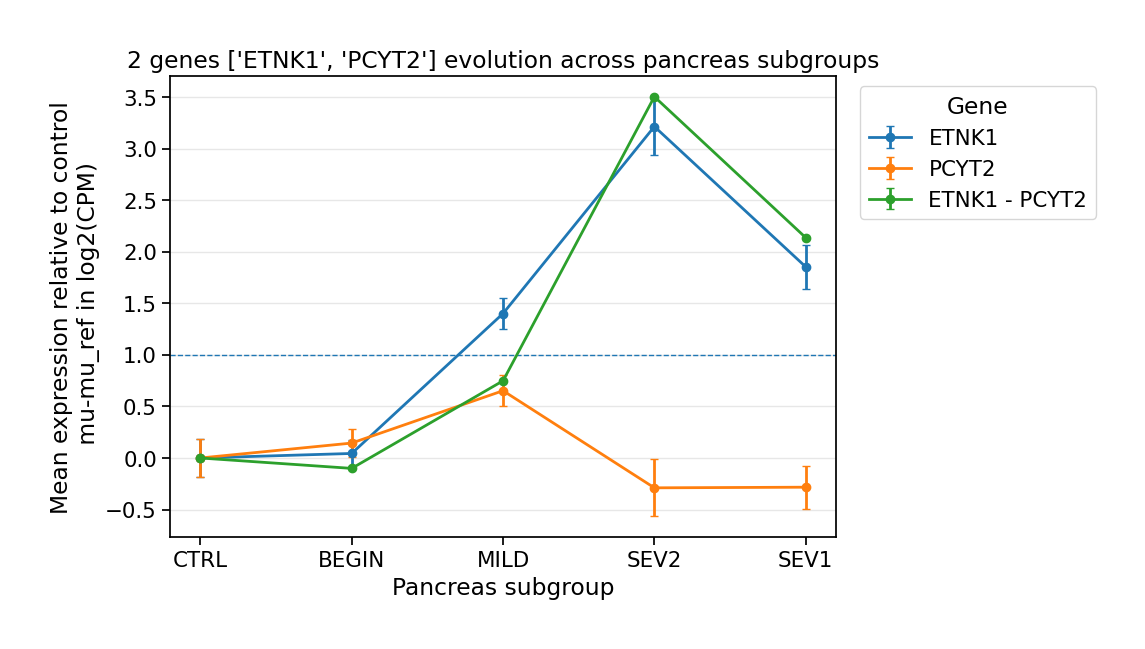

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Kennedy pathway genes
# ============================================================


# KS
gene1 = 'LPCAT1'
gene2 = 'PCYT2'

gene1 = 'CHKA'
gene2 = 'ETNK1'

gene1 = 'ETNK1'
gene2 = 'PCYT2'

genes_present = [gene1, gene2]

# ============================================================
# Define biological group order
# ============================================================

group_order = ["CTRL", "BEGIN", "MILD", "SEV2", "SEV1"]

dff = df[df["symbol"].isin(genes_present)].copy()
dff["group"] = pd.Categorical(
    dff["group"],
    categories=group_order,
    ordered=True
)

dff = dff.sort_values(["symbol", "group"])


# ============================================================
# Plot 1:
# each gene evolution across groups
# ============================================================

fig, ax = plt.subplots(figsize=(11, 6))

x_positions = np.arange(len(group_order))

for gene in genes_present:
    dfa = dff[dff["symbol"] == gene].sort_values("group")

    y = dfa["mu_ref"].to_numpy()

    if gene == genes_present[0]:
        y0 = y
    else:
        y1 = y

    yerr_lower = y - dfa["ci_inf_ref"].to_numpy()
    yerr_upper = dfa["ci_sup_ref"].to_numpy() - y
    yerr = np.vstack([yerr_lower, yerr_upper])

    ax.errorbar(
        x_positions,
        y,
        yerr=yerr,
        marker="o",
        linewidth=2,
        capsize=3,
        label=gene,
    )

ax.errorbar(
    x_positions,
    np.array(y0) - np.array(y1),
    yerr=0,
    marker="o",
    linewidth=2,
    capsize=3,
    label=genes_present[0] + " - " + genes_present[1],
)

ax.axhline(1.0, linestyle="--", linewidth=1)

ax.set_xticks(x_positions)
ax.set_xticklabels(group_order)

ax.set_xlabel("Pancreas subgroup")
ax.set_ylabel("Mean expression relative to control\n mu-mu_ref in log2(CPM)")
ax.set_title(f"2 genes {genes_present} evolution across pancreas subgroups")

ax.legend(
    title="Gene",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.grid(True, axis="y", alpha=0.3)

fig.tight_layout()
fig.savefig("kennedy_gene_evolution_mu_ref.png", dpi=300, bbox_inches="tight")
plt.show()




### Correlation

In [ ]:

# ============================================================
# Plot 2:
# gene-gene correlation heatmap
# Pearson correlation across groups using mu_ref
# ============================================================

# ============================================================
# Blank non-significant mu_ref values before correlation
# CI crosses zero => mu_ref is not clearly different from CTRL
# ============================================================

dff["mu_ref_for_corr"] = dff["mu_ref"].copy()

# Blank only non-CTRL rows whose CI crosses zero
mask_ci_crosses_zero = (
    (dff["group"] != "CTRL") &
    (dff["ci_inf_ref"] <= 0) &
    (dff["ci_sup_ref"] >= 0)
)

dff.loc[mask_ci_crosses_zero, "mu_ref_for_corr"] = np.nan

# Keep CTRL as baseline
dff.loc[dff["group"] == "CTRL", "mu_ref_for_corr"] = 0.0

pivot = (
    dff.pivot_table(
        index="group",
        columns="symbol",
        values="mu_ref_for_corr",
        observed=False,
        dropna=False,
    )
    .reindex(group_order)
    .loc[:, genes_present]
)

from scipy.stats import pearsonr

# ============================================================
# Pairwise Pearson correlation + p-value
# using only non-NaN shared groups
# ============================================================

genes = pivot.columns.tolist()

corr = pd.DataFrame(np.nan, index=genes, columns=genes)
pval = pd.DataFrame(np.nan, index=genes, columns=genes)
nval = pd.DataFrame(0, index=genes, columns=genes)

for g1 in genes:
    for g2 in genes:

        # Diagonal: gene with itself
        if g1 == g2:
            n = pivot[g1].dropna().shape[0]
            nval.loc[g1, g2] = n

            if n >= 1:
                corr.loc[g1, g2] = 1.0
                pval.loc[g1, g2] = 0.0

            continue

        # Pairwise valid values
        x = pivot[g1]
        y = pivot[g2]

        valid = x.notna() & y.notna()

        x = x[valid].astype(float).to_numpy()
        y = y[valid].astype(float).to_numpy()

        n = len(x)
        nval.loc[g1, g2] = n

        # Pearson needs at least 3 points for useful p-value
        if n >= 3:
            # Avoid constant vectors, which make Pearson undefined
            if np.std(x) == 0 or np.std(y) == 0:
                continue

            r, p = pearsonr(x, y)

            corr.loc[g1, g2] = float(r)
            pval.loc[g1, g2] = float(p)

corr_for_plot = corr.copy()
corr_for_plot[pval > 0.2] = np.nan

fig, ax = plt.subplots(figsize=(10, 8))

cmap = plt.cm.bwr.copy()
cmap.set_bad(color="white")

im = ax.imshow(
    corr_for_plot.to_numpy(dtype=float),
    vmin=-1,
    vmax=1,
    cmap=cmap,
)

ax.set_xticks(np.arange(len(corr.columns)))
ax.set_yticks(np.arange(len(corr.index)))

ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.index)

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        value = corr.iloc[i, j]

        if np.isnan(value):
            label = ""
        else:
            label = f"{value:.2f}"

        ax.text(
            j,
            i,
            label,
            ha="center",
            va="center",
            fontsize=10,
        )


ax.set_title("Gene-gene correlation across pancreas subgroups")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Pearson correlation of mu_ref")

fig.tight_layout()
fig.savefig("kennedy_gene_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


# ============================================================
# Optional: save correlation table
# ============================================================

corr.to_csv("kennedy_gene_correlation_matrix.tsv", sep="\t")